# Plot UHI intensity
- This script is used to visualize UHI insensity, urban and rural temperature.
- Simulation: CNTL, TranAlbe

In [1]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import scipy.stats as stats
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
import matplotlib.patches as patches
var_list = ['TG', 'TSA']

In [2]:
uhi_average_list = []
uhi_day_list = []
uhi_night_list = []
region = 'HK'
start_date = '2035-04-01'
end_date = '2039-12-30'
for scenario in ['cntl', 'tran_albe']:
    df_var_uhi_average = pd.read_csv(f'./data_for_figure/{region}_tmax_{scenario}_urban_rural.csv')
    df_var_uhi_average['time'] = pd.to_datetime(df_var_uhi_average['time'])
    df_var_uhi_average = df_var_uhi_average[(df_var_uhi_average['time']>=pd.to_datetime(start_date)) & (df_var_uhi_average['time']<pd.to_datetime(end_date))]
    df_var_uhi_average['time_local'] = df_var_uhi_average['time'] + pd.Timedelta(hours=8)
    df_var_uhi_average['date'] = df_var_uhi_average['time_local'].dt.date
    df_var_uhi_average_clean = df_var_uhi_average[(df_var_uhi_average['date']>=pd.to_datetime(start_date).date()) & (df_var_uhi_average['date']<pd.to_datetime(end_date).date())]
    df_var_uhi_average_clean['year-month'] = df_var_uhi_average_clean['time_local'].dt.to_period('M')
    df_var_uhi_average_month = df_var_uhi_average_clean.copy()
    df_var_uhi_average_month.drop(columns=['time', 'time_local', 'date'], inplace=True)
    df_var_uhi_average_month_group = df_var_uhi_average_month.groupby('year-month').mean().reset_index()
    df_var_uhi_average_month_group['scenario'] = scenario
    uhi_average_list.append(df_var_uhi_average_month_group)
    df_var_uhi_average_day = df_var_uhi_average_clean.copy()
    df_var_uhi_average_day['hour'] = df_var_uhi_average_day['time_local'].dt.hour
    df_var_uhi_average_day_max = df_var_uhi_average_day[df_var_uhi_average_day['hour']==14].copy() # 14:00
    df_var_uhi_average_day_max.drop(columns=['time', 'time_local', 'date', 'hour'], inplace=True)
    df_var_uhi_average_day_max_group = df_var_uhi_average_day_max.groupby('year-month').mean().reset_index()
    df_var_uhi_average_day_max_group['scenario'] = scenario
    uhi_day_list.append(df_var_uhi_average_day_max_group)
    df_var_uhi_average_day_min = df_var_uhi_average_day[df_var_uhi_average_day['hour']==2].copy() # 14:00
    df_var_uhi_average_day_min.drop(columns=['time', 'time_local', 'date', 'hour'], inplace=True)
    df_var_uhi_average_day_min_group = df_var_uhi_average_day_min.groupby('year-month').mean().reset_index()
    df_var_uhi_average_day_min_group['scenario'] = scenario
    uhi_night_list.append(df_var_uhi_average_day_min_group)
df_var_uhi_average_month_group_all = pd.concat(uhi_average_list, axis=0, ignore_index=True)
df_var_uhi_max_month_group_all = pd.concat(uhi_day_list, axis=0, ignore_index=True)
df_var_uhi_min_month_group_all = pd.concat(uhi_night_list, axis=0, ignore_index=True)
df_var_uhi_average_month_group_all

/tmp/ipykernel_2868694/905807845.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var_uhi_average_clean['year-month'] = df_var_uhi_average_clean['time_local'].dt.to_period('M')
/tmp/ipykernel_2868694/905807845.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var_uhi_average_clean['year-month'] = df_var_uhi_average_clean['time_local'].dt.to_period('M')


,year-month,TSA_urban,TG_urban,TSA_rural,TG_rural,TSA_uhi,TG_uhi,scenario
0,2035-04,26.264113,29.944704,24.791267,26.448657,1.472847,3.496047,cntl
1,2035-05,28.480219,32.341833,26.855642,28.467790,1.624577,3.874043,cntl
2,2035-06,31.258781,36.814652,29.337907,31.969901,1.920874,4.844751,cntl
3,2035-07,31.207478,35.665211,29.682950,31.939794,1.524529,3.725417,cntl
4,2035-08,30.900366,35.108414,29.354478,31.347670,1.545888,3.760744,cntl
...,...,...,...,...,...,...,...,...
109,2039-08,31.077601,35.120426,29.465375,32.302609,1.612226,2.817817,tran_albe
110,2039-09,29.528812,31.892100,28.419871,29.998608,1.108941,1.893492,tran_albe
111,2039-10,25.977538,27.929755,24.939154,26.330126,1.038384,1.599629,tran_albe
112,2039-11,19.806984,21.499064,18.712822,20.088666,1.094162,1.410398,tran_albe


In [3]:
df_cntl = pd.read_csv(f'./data_for_figure/{region}_tmax_cntl_urban_rural.csv')
df_cntl['time'] = pd.to_datetime(df_cntl['time'])
df_cntl = df_cntl.set_index("time")
df_tran = pd.read_csv(f'./data_for_figure/{region}_tmax_tran_albe_urban_rural.csv')
df_tran['time'] = pd.to_datetime(df_tran['time'])
df_tran = df_tran.set_index("time")
df_delta = df_tran - df_cntl
df_delta_clean = df_delta[(df_delta.index.date>=pd.to_datetime(start_date).date()) & (df_delta.index.date<pd.to_datetime(end_date).date())]
df_delta_clean.head()

,TSA_urban,TG_urban,TSA_rural,TG_rural,TSA_uhi,TG_uhi
time,,,,,,
2035-04-01 00:00:00,-0.007096,-0.032521,-0.000464,-0.000553,-0.006632,-0.031968
2035-04-01 01:00:00,-0.008272,-0.052437,-0.000916,-0.001271,-0.007356,-0.051166
2035-04-01 02:00:00,-0.009914,-0.072749,-0.001105,-0.001785,-0.008809,-0.070964
2035-04-01 03:00:00,-0.011108,-0.088894,-0.001171,-0.002120,-0.009937,-0.086773
2035-04-01 04:00:00,-0.011901,-0.099325,-0.001223,-0.002284,-0.010678,-0.097041


In [4]:
label_list = ['uhi', 'urban', 'rural']
labelcolor = '#6b6b6b'
linewidth = 0.5
varname_list = ['SUHII', 'CUHII', 'TG_U', 'TSA_U', 'TG_R', 'TSA_R']
corr_pairs = [("TG_uhi", "TSA_uhi"), ("TG_urban", "TSA_urban"), ("TG_rural", "TSA_rural")]
label_pairs = [("SUHII", "CUHII"), ("TG_U", "TSA_U"), ("TG_R", "TSA_R")]
fontsize = 6
padding = 4
boundarywidth = 0.5
ticks = ['2035-04', '2036-01', '2037-01', '2038-01', '2039-01']
tick_labels = ['', '2036', '2037', '2038', '2039']
labelsize = 6
length = 4
pad = 1

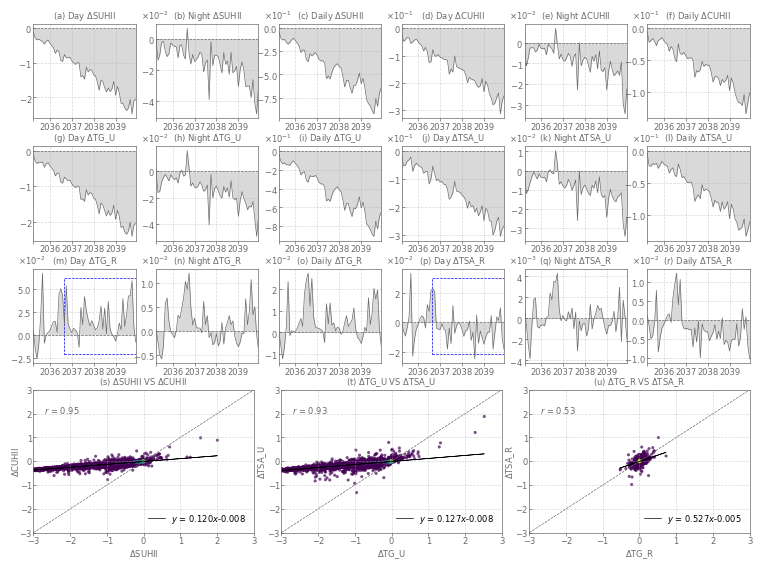

In [6]:
nrows_main = len(label_list)  # 3 rows (original)
ncols_main = 6                # 6 columns (original)
ncols_bottom = 3              # 3 columns for the bottom row
# Total rows = main rows (3) + bottom row (1) = 4
# Total columns = 6 (to align with main grid)
fig = plt.figure(figsize=(7.5, 5.5))  # Slightly taller fig to fit bottom row
'''
gs = gridspec.GridSpec(nrows=4,          # 4 total rows (3 main + 1 bottom)
                       ncols=6,          # 6 total columns
                       height_ratios=[1, 1, 1, 1.5],  # Bottom row slightly shorter (adjust as needed)
                       hspace=0.25        # Vertical spacing between rows
                      )
axes_main = []
for i in range(nrows_main):
    row_axes = []
    for j in range(ncols_main):
        ax = fig.add_subplot(gs[i, j])  # i=0/1/2 (rows), j=0-5 (columns)
        row_axes.append(ax)
    axes_main.append(row_axes)
axes_main = np.array(axes_main)  # Convert to 2D array (like plt.subplots output)

axes_bottom = [fig.add_subplot(gs[3, 0:2]),  # Bottom row, column 1
               fig.add_subplot(gs[3, 2:4]),  # Bottom row, column 2
               fig.add_subplot(gs[3, 4:6])   # Bottom row, column 3
              ]     
ax = axes_main.flatten()                               
'''
outer_gs = gridspec.GridSpec(
    nrows=4,
    ncols=1,
    height_ratios=[1, 1, 1, 1.5],
    hspace=0.25
)
top_gs = outer_gs[:3].subgridspec(
    nrows=3,
    ncols=6,
    wspace=0.2,
    hspace=0.3
)
bottom_gs = outer_gs[3].subgridspec(
    nrows=1,
    ncols=3,
    wspace=0.125
)
ax = [fig.add_subplot(top_gs[i, j]) for i in range(3) for j in range(6)]
axes_bottom = [fig.add_subplot(bottom_gs[0, j]) for j in range(3)]

nrows = len(label_list)
ncols = 6
for i in range(nrows*ncols):
    index_row = i // ncols
    index_col = i % ncols
    if index_col in [0, 3]:
        data = df_var_uhi_max_month_group_all
        time_tag = 'Day'
    elif index_col in [1, 4]:
        data = df_var_uhi_min_month_group_all    
        time_tag = 'Night'
    else:
        data = df_var_uhi_average_month_group_all
        time_tag = 'Daily'
    if index_col in [0, 1, 2]:
        index_var = 'TG'
    elif index_col in [3, 4, 5]:
        index_var = 'TSA' 
    tag = label_list[index_row]     
    varname = varname_list[i // 3]  
    title = f'({string.ascii_lowercase[i]}) {time_tag}' +r' $\Delta$' + f'{varname}'
    ax[i].set_title(title, color=labelcolor, fontsize=fontsize, pad=4)
    index_varname = f'{index_var}_{tag}'
    data_cntl = data[data['scenario']=='cntl']
    data_tran = data[data['scenario']=='tran_albe']
    data_delta = data_tran[index_varname].values - data_cntl[index_varname].values 
    time_list = data_cntl['year-month'].astype(str)                
    ax[i].plot(time_list, data_delta, linewidth=linewidth, color=labelcolor)
    ax[i].fill_between(time_list, data_delta, 0, color=labelcolor, alpha=0.25,
                       linewidth=0)
    ax[i].axhline(0, color=labelcolor, linewidth=linewidth, linestyle='--') 
    for spine in ax[i].spines.values():
        spine.set_linewidth(boundarywidth)
        spine.set_edgecolor(labelcolor)  
    ax[i].set_xticks(ticks)
    ax[i].set_xticklabels(tick_labels, fontsize=fontsize, color=labelcolor)  
    ax[i].set_xlim(time_list.iloc[0], time_list.iloc[-1]) 
    ax[i].ticklabel_format(style='scientific', scilimits=(0,0), axis='y')
    ax[i].yaxis.major.formatter._useMathText = True
    ax[i].yaxis.offsetText.set_fontsize(fontsize)
    ax[i].yaxis.offsetText.set_position((-0.15, 0.25))  
    '''
    if index_row == 2:
        labelbottom=True
    else:
        labelbottom=False    
    '''    
    ax[i].tick_params(axis='y', labelleft=True, labelsize=labelsize, direction='in', length=length/2, 
                      pad=pad, width = boundarywidth,colors=labelcolor)
    ax[i].tick_params(axis='x', labelbottom=True, labelsize=labelsize, length=length/2, 
                      pad=pad, width = boundarywidth,colors=labelcolor)   
    ax[i].grid(True, which='both', axis='both',linestyle='--',linewidth=linewidth, alpha=0.5)
    
    if i in [12, 15]:
        square = patches.Rectangle((0.3, 0.1),  # bottom-left in axes coordinates
                                    0.7, 0.8,  # width, height (axes fraction)
                                    linewidth=linewidth,
                                    edgecolor='blue',
                                    facecolor='none',
                                    linestyle='dashed',
                                    transform=ax[i].transAxes  # coordinates 0–1 in axes
                                    )
        ax[i].add_patch(square)

corr_results = []
for idx, ((var1, var2), ax, (varname1, varname2)) in enumerate(zip(corr_pairs, axes_bottom, label_pairs)):
    x = df_delta_clean[var1]
    y = df_delta_clean[var2]
    # Pearson correlation (linear relationship)
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    corr_results.append({
        "Variable Pair": f"{var1} ↔ {var2}",
        "Pearson r": round(pearson_r, 3),
        "Pearson p-value": f"{pearson_p:.2e}" if pearson_p < 0.001 else round(pearson_p, 3),
        "Significant (p<0.05)": "Yes" if (pearson_p < 0.05 and spearman_p < 0.05) else "No"
    })
    corr_df = pd.DataFrame(corr_results)
    #ax.scatter(x, y, color=labelcolor, alpha=0.5, s=10)  # s=10 = small points for dense data
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    density = kde(xy)
    scatter = ax.scatter(x, y, c=density, cmap='viridis', alpha=0.7, s=5, edgecolors='none')
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), color="black", linestyle="-", linewidth=linewidth, 
            label=r'$y$' + f' = {z[0]:.3f}' + r'$x$' + f'{z[1]:.3f}')
    pearson_r = corr_df.loc[idx, "Pearson r"]
    #r_squared = pearson_r**2
    #r2_formatted = f"{r_squared:.2f}"
    #text_str = r'R$^2$' + f' = {r2_formatted}'
    r_formatted = f"{pearson_r:.2f}"
    text_str = r'$r$' + f' = {r_formatted}'
    ax.text(0.05, 0.9, text_str, transform=ax.transAxes, verticalalignment="top", color=labelcolor, fontsize=fontsize)
    ax.set_title(f'({string.ascii_lowercase[idx+nrows*ncols]}) ' + r'$\Delta$' + f'{varname1} VS ' + r'$\Delta$' + f'{varname2}', 
                 fontsize=fontsize, color=labelcolor, pad=4)
    ax.legend(fontsize=fontsize, frameon=False)
    ax.tick_params(axis='y', labelleft=True, labelsize=labelsize, direction='in', length=length/2, pad=pad, 
                   width=boundarywidth,colors=labelcolor)
    ax.tick_params(axis='x', labelsize=labelsize, length=length/2, pad=pad, width = boundarywidth,colors=labelcolor)   
    ax.grid(True, which='both', axis='both',linestyle='--',linewidth=linewidth, alpha=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(boundarywidth)
        spine.set_edgecolor(labelcolor)  
    ax.set_ylim(-3, 3)
    ax.set_xlim(-3, 3)
    ax.plot([-3, 3], [-3, 3], color=labelcolor, linewidth=linewidth, linestyle='dashed')
    ax.set_xlabel(r'$\Delta$' + f'{varname1}', color=labelcolor, fontsize=labelsize, labelpad=pad)
    ax.set_ylabel(r'$\Delta$' + f'{varname2}', color=labelcolor, fontsize=labelsize, labelpad=-pad)
  
plt.subplots_adjust(left=0.0325, right=0.9875, bottom=0.05, top=0.975) 
fig.savefig('uhi_changes.png', dpi=300)  
fig.savefig('uhi_changes.pdf', dpi=600)        

In [ ]:
corr_df

,Variable Pair,Pearson r,Pearson p-value,Significant (p<0.05)
0,TG_uhi ↔ TSA_uhi,0.960,0.00e+00,Yes
1,TG_urban ↔ TSA_urban,0.930,0.00e+00,Yes
2,TG_rural ↔ TSA_rural,0.507,0.00e+00,Yes


In [ ]:
corr_pairs = [("TSA_uhi", "TG_uhi"), ("TSA_urban", "TG_urban"), ("TSA_rural", "TG_rural")]

for var1, var2 in corr_pairs:
    # Pearson correlation (linear relationship)
    pearson_r, pearson_p = stats.pearsonr(df_delta_clean[var1], df_delta_clean[var2])
    # Spearman correlation (non-linear/rank-based relationship)
    spearman_r, spearman_p = stats.spearmanr(df_delta_clean[var1], df_delta_clean[var2])
    
    corr_results.append({
        "Variable Pair": f"{var1} ↔ {var2}",
        "Pearson r": round(pearson_r, 3),
        "Pearson p-value": f"{pearson_p:.2e}" if pearson_p < 0.001 else round(pearson_p, 3),
        "Spearman ρ": round(spearman_r, 3),
        "Spearman p-value": f"{spearman_p:.2e}" if spearman_p < 0.001 else round(spearman_p, 3),
        "Significant (p<0.05)": "Yes" if (pearson_p < 0.05 and spearman_p < 0.05) else "No"
    })

# Convert results to DataFrame for readability
corr_df = pd.DataFrame(corr_results)
print("=== Correlation Analysis Results ===")
print(corr_df.to_string(index=False))

# Description

In [5]:
df_cntl_clean = df_cntl[(df_cntl.index.date>=pd.to_datetime('2035-01-01').date()) & (df_cntl.index.date<pd.to_datetime(end_date).date())]
df_cntl_clean_annual = df_cntl_clean.reset_index()
df_cntl_clean_annual['year'] = df_cntl_clean_annual['time'].dt.year
df_cntl_clean_annual_mean = df_cntl_clean_annual.groupby('year').mean()
df_cntl_clean_annual_mean

,time,TSA_urban,TG_urban,TSA_rural,TG_rural,TSA_uhi,TG_uhi
year,,,,,,,
2035,2035-07-02 11:30:00.000000000,24.879266,28.390537,23.480286,25.260628,1.398980,3.129909
2036,2036-07-01 11:37:43.561644032,24.060461,27.866581,22.595191,24.733486,1.465270,3.133095
2037,2037-07-02 11:30:00.000000000,24.840312,28.421701,23.416210,25.324755,1.424102,3.096946
2038,2038-07-02 11:30:00.000000256,24.307178,27.963171,22.881447,24.864859,1.425731,3.098313
2039,2039-07-01 11:30:00.000000000,24.818438,28.271923,23.435482,25.261731,1.382956,3.010192


In [6]:
df_tran_clean = df_tran[(df_tran.index.date>=pd.to_datetime('2035-01-01').date()) & (df_tran.index.date<pd.to_datetime(end_date).date())]
df_tran_clean_annual = df_tran_clean.reset_index()
df_tran_clean_annual['year'] = df_tran_clean_annual['time'].dt.year
df_tran_clean_annual_mean = df_tran_clean_annual.groupby('year').mean()
df_tran_clean_annual_mean

,time,TSA_urban,TG_urban,TSA_rural,TG_rural,TSA_uhi,TG_uhi
year,,,,,,,
2035,2035-08-15 12:00:00.000000000,26.812729,30.455742,25.352171,27.200447,1.460558,3.255295
2036,2036-07-01 11:37:43.561644032,24.029550,27.623921,22.598481,24.744590,1.431069,2.879331
2037,2037-07-02 11:30:00.000000000,24.779888,28.007479,23.412749,25.328350,1.367139,2.679129
2038,2038-07-02 11:30:00.000000256,24.226832,27.401612,22.877528,24.867746,1.349304,2.533866
2039,2039-07-01 11:30:00.000000000,24.706250,27.527862,23.431237,25.268122,1.275013,2.259740


In [14]:
df_var_uhi_max_month_group_all_jja_2039 = df_var_uhi_max_month_group_all[
    (df_var_uhi_max_month_group_all['year-month'].dt.year == 2039) &
    (df_var_uhi_max_month_group_all['year-month'].dt.month.isin([6,7,8]))
].copy()

df_var_uhi_max_month_group_all_jja_2039

,year-month,TSA_urban,TG_urban,TSA_rural,TG_rural,TSA_uhi,TG_uhi,scenario
50,2039-06,34.418616,45.883693,32.270558,37.177502,2.148058,8.706191,cntl
51,2039-07,35.454412,49.658227,33.153686,39.280764,2.300725,10.377462,cntl
52,2039-08,35.385590,48.565618,33.410514,39.913288,1.975076,8.652330,cntl
107,2039-06,34.119719,43.594892,32.252416,37.186282,1.867303,6.408610,tran_albe
108,2039-07,35.173315,47.302884,33.146552,39.302291,2.026763,8.000594,tran_albe
109,2039-08,35.135048,46.294348,33.414276,39.955335,1.720772,6.339013,tran_albe


In [20]:
tg_r_jja2039 = (df_var_uhi_max_month_group_all_jja_2039[df_var_uhi_max_month_group_all_jja_2039['scenario']=='tran_albe']['TG_rural'].values - df_var_uhi_max_month_group_all_jja_2039[df_var_uhi_max_month_group_all_jja_2039['scenario']=='cntl']['TG_rural'].values).mean()
np.round(tg_r_jja2039, 2)

np.float64(0.02)

In [29]:
tg_air_jja2039 = (df_var_uhi_max_month_group_all_jja_2039[df_var_uhi_max_month_group_all_jja_2039['scenario']=='tran_albe']['TSA_rural'].values - df_var_uhi_max_month_group_all_jja_2039[df_var_uhi_max_month_group_all_jja_2039['scenario']=='cntl']['TSA_rural'].values).mean()
np.round(tg_air_jja2039, 2)

np.float64(-0.01)

In [22]:
df_var_uhi_max_month_group_all_2039 = df_var_uhi_max_month_group_all[
    (df_var_uhi_max_month_group_all['year-month'].dt.year == 2039)
].copy()

df_var_uhi_max_month_group_all_2039.head()

,year-month,TSA_urban,TG_urban,TSA_rural,TG_rural,TSA_uhi,TG_uhi,scenario
45,2039-01,22.145941,31.525293,20.464659,23.348409,1.681282,8.176884,cntl
46,2039-02,22.737002,32.729346,21.015891,24.964303,1.721111,7.765043,cntl
47,2039-03,27.586647,38.365622,25.539729,30.489168,2.046918,7.876454,cntl
48,2039-04,29.816248,44.104520,27.320216,33.734886,2.496032,10.369633,cntl
49,2039-05,32.638169,44.582904,30.504331,36.032140,2.133838,8.550764,cntl


In [27]:
tg_r_2039 = (df_var_uhi_max_month_group_all_2039[df_var_uhi_max_month_group_all_2039['scenario']=='tran_albe']['TG_rural'].values - df_var_uhi_max_month_group_all_2039[df_var_uhi_max_month_group_all_2039['scenario']=='cntl']['TG_rural'].values)
np.round(tg_r_2039.mean(), 2)

np.float64(0.02)

In [28]:
tg_r_2039

array([-0.00704675,  0.00057609,  0.01271897,  0.00527085,  0.03910518,
        0.00877965,  0.02152632,  0.04204712,  0.04212334,  0.0585782 ,
        0.00900217, -0.00789506])